# Flag non-humanoid / non-creature images

CLIP zero-shot classifies every chathead and body image into one of three buckets:
- a humanoid character
- an animal / monster / fantastical creature
- not a character at all (icon, object, texture, junk)

Anything that lands in the third bucket is a candidate for removal from the dataset —
same kind of problem as the faux-chathead nav icons found in `temp_delete_faux_chatheads.ipynb`,
but caught visually instead of via URL filename matching, and applied to both chatheads and bodies.

Workflow:
1. Run CLIP over every image, get a predicted label + confidence.
2. Pull out the images predicted "not a creature" above a confidence threshold.
3. Page through them visually below and note any false positives.
4. Save the final, human-reviewed list to `../data/flagged_junk_images.csv`.

A separate notebook (`delete_flagged_images.ipynb`) reads that CSV and deletes the files —
share the CSV with groupmates so everyone prunes the same images from their own copy of the data.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using: {device}")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using: cpu


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [2]:
df = pd.read_csv("../data/npc.csv")
df["has_chathead"] = df["id"].apply(lambda i: os.path.exists(f"../data/chatheads/{i}.png"))
df["has_body"] = df["id"].apply(lambda i: os.path.exists(f"../data/bodies/{i}.png"))

df = df.rename(columns={"Race": "Class"})
print(f"{df['has_chathead'].sum()} chatheads, {df['has_body'].sum()} bodies on disk")

3477 chatheads, 4423 bodies on disk


## Classifier

Text embeddings for the three categories are computed once and reused for every image
(instead of re-encoding the same three prompts thousands of times). Images are classified
in batches for speed — there are ~3,500 chatheads and ~3,500 bodies to get through.

In [3]:
CATEGORIES = [
    "a photo of a humanoid person or character",
    "a photo of an animal, monster, or fantastical creature",
    "a photo that shows no character or creature at all, such as an icon, object, or texture",
]
LABELS = ["humanoid", "creature", "non_creature"]
NON_CREATURE_LABEL = "non_creature"

text_inputs = clip_processor(text=CATEGORIES, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_embeds = clip_model.get_text_features(**text_inputs).cpu().numpy()
text_embeds = normalize(text_embeds)
logit_scale = clip_model.logit_scale.exp().item()


def softmax(x, axis=1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def classify_batch(image_paths, batch_size=64):
    all_probs = []
    for start in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[start:start + batch_size]
        imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = clip_processor(images=imgs, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            img_embeds = clip_model.get_image_features(**inputs).cpu().numpy()
        img_embeds = normalize(img_embeds)
        logits = (img_embeds @ text_embeds.T) * logit_scale
        all_probs.append(softmax(logits))
        if start % (batch_size * 10) == 0:
            print(f"{start}/{len(image_paths)}")
    return np.vstack(all_probs)

In [4]:
FOLDER_TYPE = {"chatheads": "chathead", "bodies": "body"}


def scan_folder(folder, npc_ids):
    paths = [f"../data/{folder}/{i}.png" for i in npc_ids]
    probs = classify_batch(paths)
    pred_idx = probs.argmax(axis=1)
    return pd.DataFrame({
        "id": npc_ids,
        "type": FOLDER_TYPE[folder],
        "humanoid_prob": probs[:, 0],
        "creature_prob": probs[:, 1],
        "non_creature_prob": probs[:, 2],
        "predicted_label": [LABELS[i] for i in pred_idx],
        "confidence": probs[np.arange(len(probs)), pred_idx],
    })

In [5]:
chathead_ids = df[df["has_chathead"]]["id"].tolist()
body_ids = df[df["has_body"]]["id"].tolist()

chathead_results = scan_folder("chatheads", chathead_ids)
body_results = scan_folder("bodies", body_ids)

flags_df = pd.concat([chathead_results, body_results], ignore_index=True)
flags_df = flags_df.merge(df[["id", "Name"]], on="id", how="left")
print(f"Classified {len(flags_df)} images")
flags_df["predicted_label"].value_counts()

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


0/3477


C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\b

640/3477


C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\b

...

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


3840/4423


C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Classified 7900 images


predicted_label
humanoid        7073
creature         566
non_creature     261
Name: count, dtype: int64

In [6]:
THRESHOLD = 0.6

candidates = flags_df[
    (flags_df["predicted_label"] == NON_CREATURE_LABEL) & (flags_df["confidence"] >= THRESHOLD)
].sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"{len(candidates)} candidates flagged as non-humanoid / non-creature")
candidates["type"].value_counts()

129 candidates flagged as non-humanoid / non-creature


type
body        123
chathead      6
Name: count, dtype: int64

## Visual review

Page through the flagged candidates below (`page=0`, `page=1`, ...) and check each grid for
false positives — real chatheads/bodies CLIP got wrong. Note their `id` and `type`.

In [7]:
def review_grid(candidates_df, page=0, page_size=20, cols=5):
    subset = candidates_df.iloc[page * page_size:(page + 1) * page_size]
    rows = -(-page_size // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    for ax, (_, row) in zip(axes.flat, subset.iterrows()):
        folder = "chatheads" if row["type"] == "chathead" else "bodies"
        img = Image.open(f"../data/{folder}/{row['id']}.png")
        ax.imshow(img)
        ax.set_title(f"{row['id']}: {row['Name']}\n{row['type']} ({row['confidence']:.2f})", fontsize=9)
        ax.axis("off")
    for ax in axes.flat[len(subset):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Showing {page * page_size}-{min((page + 1) * page_size, len(candidates_df))} of {len(candidates_df)}")

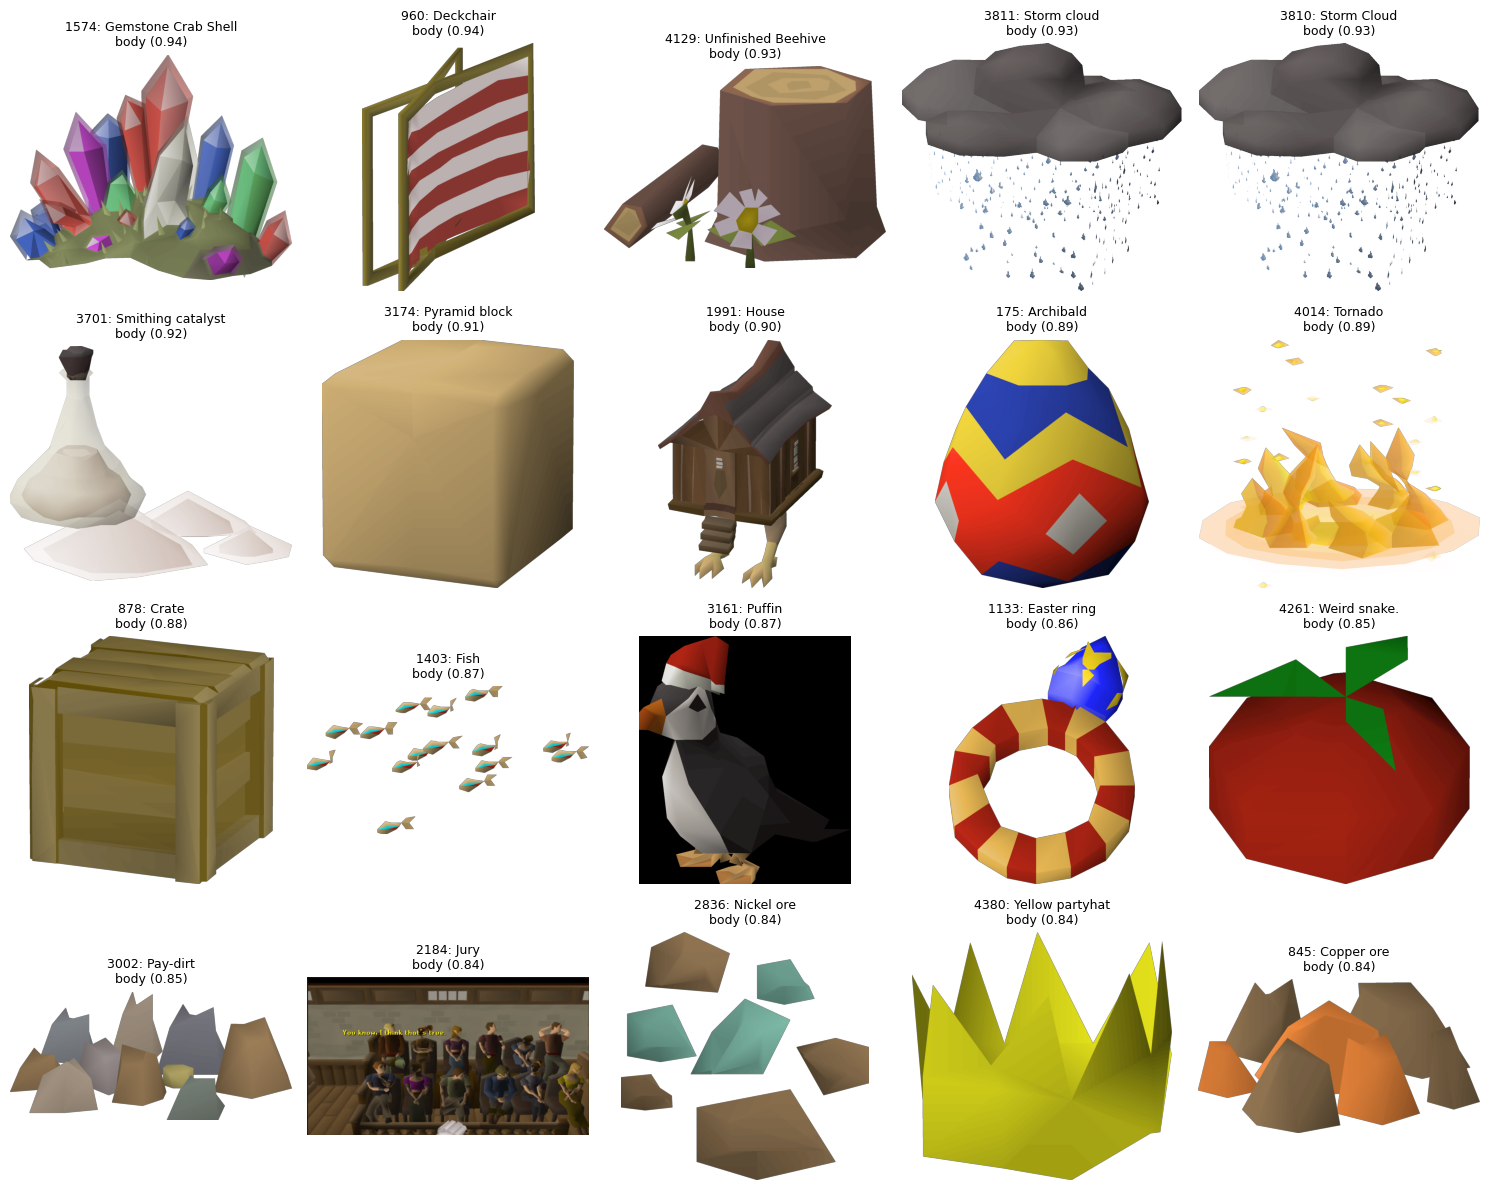

Showing 0-20 of 129


In [8]:
review_grid(candidates, page=0)

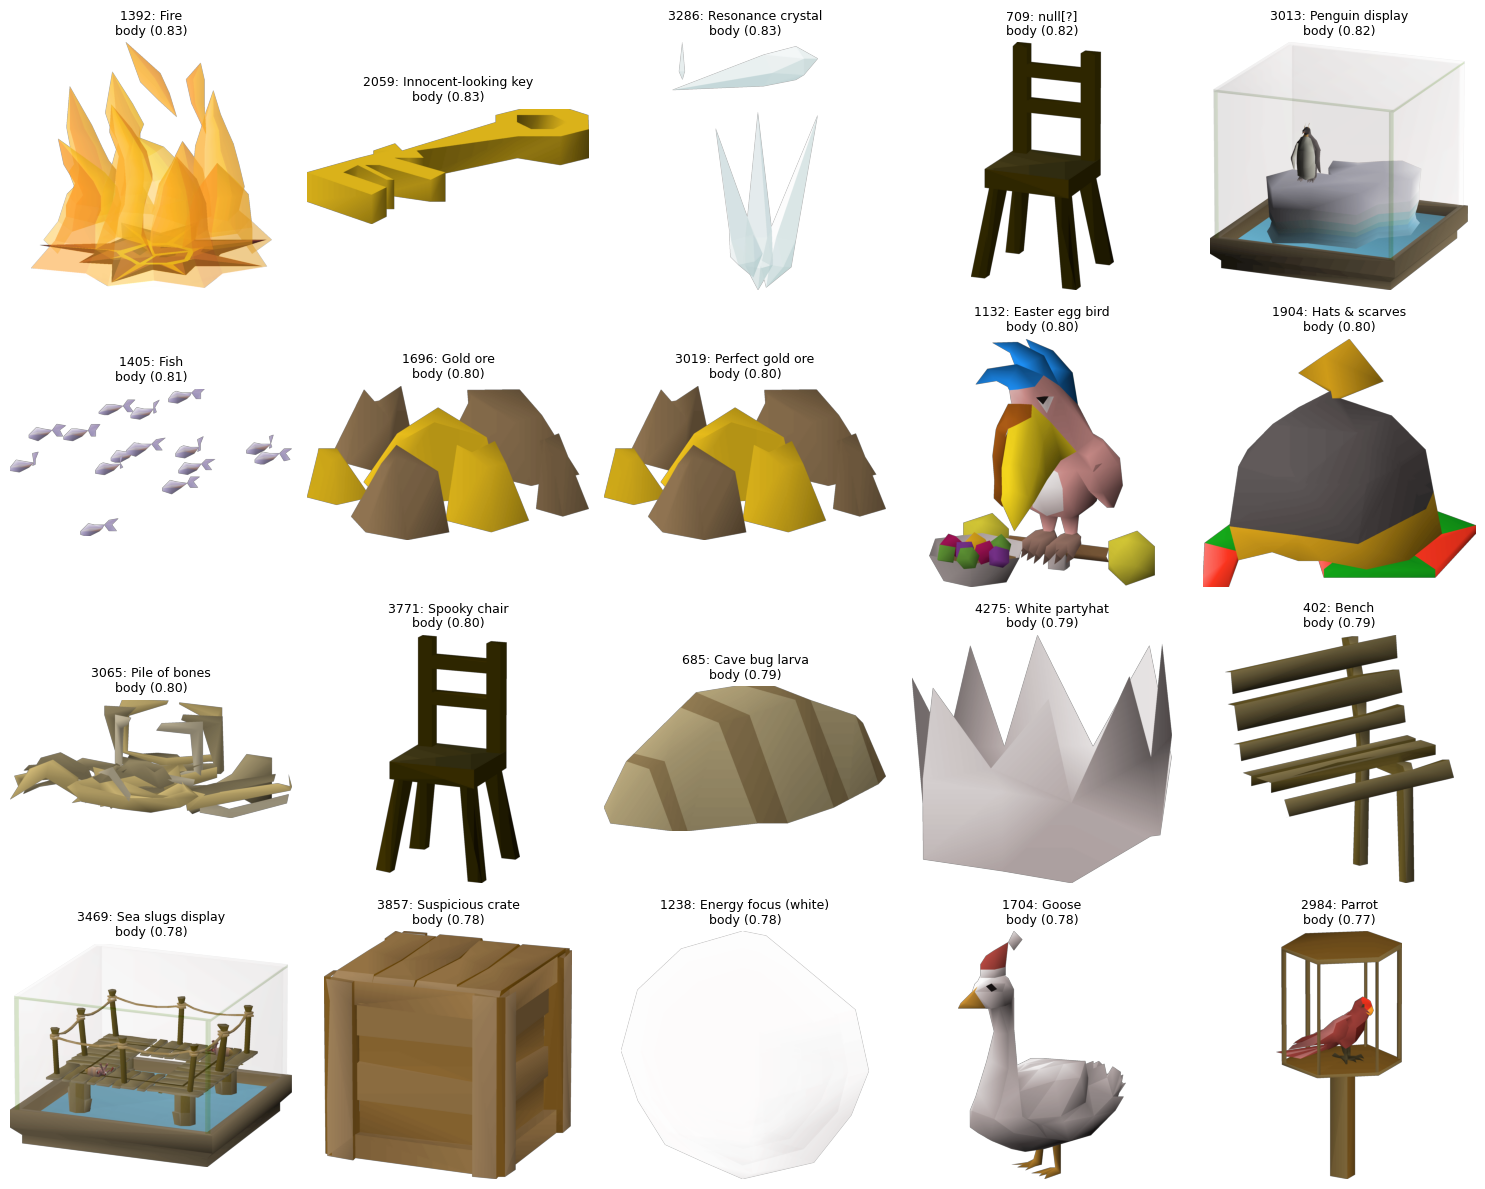

Showing 20-40 of 129


In [9]:
review_grid(candidates, page=1)

## Save candidates for review

Write out the raw candidate list for one-by-one visual review in `review_app.py`
(`streamlit run review_app.py`), which reads this file and produces
`../data/flagged_junk_images.csv` (remove decisions only) as you go.

In [ ]:
candidates[["id", "type", "Name", "confidence"]].to_csv("../data/flagged_candidates.csv", index=False)
print(f"Saved {len(candidates)} candidates to ../data/flagged_candidates.csv")
candidates["type"].value_counts()